## Model Training


#### 1.1 Import Data and Required Packages
##### Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

#### Import the CSV Data as Pandas DataFrame


In [36]:
import pandas as pd

In [37]:
df=pd.read_csv(r'C:\Users\koiri\OneDrive\Desktop\Customer Churn Prediction\notebook\data\customer_churn_cleaned.csv')

In [38]:
df.head(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [39]:
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    print(f"\n{col}")
    print(df[col].unique())


gender
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

Partner
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

Dependents
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

PhoneService
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

MultipleLines
<StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

InternetService
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

OnlineSecurity
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

OnlineBackup
<StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str

DeviceProtection
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

TechSupport
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

StreamingTV
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

StreamingMovies
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

Contract
<StringArray>
['Month-to-month', 'One year', '

C:\Users\koiri\AppData\Local\Temp\ipykernel_25832\3655717326.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


In [40]:
cols = [
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

df['MultipleLines'] = df['MultipleLines'].replace('No phone service', 'No')

for col in cols:
    df[col] = df[col].replace('No internet service', 'No')

In [41]:
df['MultipleLines'].unique()
df['OnlineSecurity'].unique()
df['OnlineBackup'].unique()
df['DeviceProtection'].unique()
df['TechSupport'].unique()
df['StreamingTV'].unique()
df['StreamingMovies'].unique()

<StringArray>
['No', 'Yes']
Length: 2, dtype: str

In [42]:
df.nunique()

gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                72
PhoneService           2
MultipleLines          2
InternetService        3
OnlineSecurity         2
OnlineBackup           2
DeviceProtection       2
TechSupport            2
StreamingTV            2
StreamingMovies        2
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1584
TotalCharges        6530
Churn                  2
dtype: int64

In [43]:
df['Contract'].unique()

<StringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str

In [44]:
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

categorical_features = df.select_dtypes(include=['object', 'string']).columns.tolist()


print(f"We have {len(numeric_features)} numerical features: {numeric_features}")
print(f"We have {len(categorical_features)} categorical features: {categorical_features}")

We have 4 numerical features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
We have 16 categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [45]:
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

In [46]:
X=df.drop('Churn', axis=1)
y=df['Churn']

In [47]:
# Create Column Transformer with 3 types of transformers
num_features = X.select_dtypes(exclude="object").columns
cat_features = X.select_dtypes(include="object").columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
         ("StandardScaler", numeric_transformer, num_features),        
    ]
)

C:\Users\koiri\AppData\Local\Temp\ipykernel_25832\3513031509.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = X.select_dtypes(include="object").columns


In [49]:
X.shape

(7032, 19)

In [50]:
y.shape

(7032,)

In [52]:
# separate dataset into train and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape, X_test.shape
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)
X_train.shape, X_test.shape



((5625, 38), (1407, 38))

In [53]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print(y_train_smote.value_counts())

Churn
1    4130
0    4130
Name: count, dtype: int64


In [54]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True, random_state=42),
    "Naive Bayes": GaussianNB()
}

In [56]:
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = []

for name, model in models.items():

    model.fit(X_train_smote, y_train_smote)

    # Train predictions
    y_train_pred = model.predict(X_train)
    y_train_prob = model.predict_proba(X_train)[:, 1]

    # Test predictions
    y_test_pred = model.predict(X_test)
    y_test_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Train Accuracy": round(accuracy_score(y_train, y_train_pred), 4),
        "Test Accuracy": round(accuracy_score(y_test, y_test_pred), 4),
        "Train F1": round(f1_score(y_train, y_train_pred), 4),
        "Test F1": round(f1_score(y_test, y_test_pred), 4),

        "Train Recall": round(recall_score(y_train, y_train_pred), 4),
        "Test Recall": round(recall_score(y_test, y_test_pred), 4),

        "Train Precision": round(precision_score(y_train, y_train_pred), 4),
        "Test Precision": round(precision_score(y_test, y_test_pred), 4),

        "Train ROC AUC": round(roc_auc_score(y_train, y_train_prob), 4),
        "Test ROC AUC": round(roc_auc_score(y_test, y_test_prob), 4)
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by=["Test F1", "Test ROC AUC"],
    ascending=False
)

print(results_df)

                 Model  Train Accuracy  Test Accuracy  Train F1  Test F1  \
0  Logistic Regression          0.7568         0.7377    0.6377   0.6176   
4             AdaBoost          0.7612         0.7385    0.6371   0.6134   
6                  SVM          0.8112         0.7576    0.6932   0.6103   
3    Gradient Boosting          0.8073         0.7697    0.6650   0.6096   
7          Naive Bayes          0.7479         0.7356    0.6204   0.6092   
2        Random Forest          0.9977         0.7704    0.9957   0.5593   
5                  KNN          0.8030         0.6745    0.7135   0.5447   
1        Decision Tree          0.9977         0.7186    0.9956   0.5363   

   Train Recall  Test Recall  Train Precision  Test Precision  Train ROC AUC  \
0        0.8054       0.7968           0.5278          0.5042         0.8511   
4        0.7886       0.7807           0.5345          0.5052         0.8529   
6        0.8027       0.7139           0.6101          0.5329         0.887

In [57]:
results_df.head(5)

,Model,Train Accuracy,Test Accuracy,Train F1,Test F1,Train Recall,Test Recall,Train Precision,Test Precision,Train ROC AUC,Test ROC AUC
0,Logistic Regression,0.7568,0.7377,0.6377,0.6176,0.8054,0.7968,0.5278,0.5042,0.8511,0.8318
4,AdaBoost,0.7612,0.7385,0.6371,0.6134,0.7886,0.7807,0.5345,0.5052,0.8529,0.8280
6,SVM,0.8112,0.7576,0.6932,0.6103,0.8027,0.7139,0.6101,0.5329,0.8874,0.8105
3,Gradient Boosting,0.8073,0.7697,0.6650,0.6096,0.7197,0.6765,0.6180,0.5548,0.8700,0.8294
7,Naive Bayes,0.7479,0.7356,0.6204,0.6092,0.7753,0.7754,0.5172,0.5017,0.8331,0.8146


In [58]:
best_model = results_df.sort_values(
    by=['Test F1', 'Test ROC AUC'],
    ascending=False
).iloc[0]

print(best_model)

Model              Logistic Regression
Train Accuracy                  0.7568
Test Accuracy                   0.7377
Train F1                        0.6377
Test F1                         0.6176
Train Recall                    0.8054
Test Recall                     0.7968
Train Precision                 0.5278
Test Precision                  0.5042
Train ROC AUC                   0.8511
Test ROC AUC                    0.8318
Name: 0, dtype: object


In [59]:
best_model_name = best_model["Model"]

print("Best Model:", best_model_name)

Best Model: Logistic Regression


In [60]:
final_model = models[best_model_name]

final_model.fit(X_train_smote, y_train_smote)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [61]:
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Predictions
y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 1]

print(f"Accuracy : {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"Recall   : {recall_score(y_test, y_pred)*100:.2f}%")
print(f"F1 Score : {f1_score(y_test, y_pred)*100:.2f}%")
print(f"ROC AUC  : {roc_auc_score(y_test, y_prob)*100:.2f}%")

Accuracy : 73.77%
Recall   : 79.68%
F1 Score : 61.76%
ROC AUC  : 83.18%


In [62]:
pred_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred,
    "Probability": y_prob
})

pred_df.head(20)

,Actual,Predicted,Probability
2476,0,0,0.012149
6773,0,0,0.257111
6116,1,1,0.867194
3047,0,0,0.276232
4092,0,1,0.568676
3218,0,1,0.703862
3768,0,0,0.295438
3463,0,1,0.894210
3414,0,0,0.393979
1192,0,0,0.051499


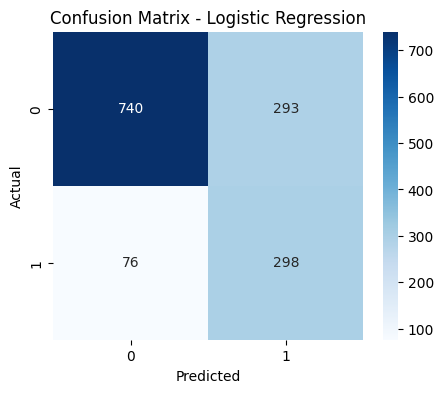

In [63]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_model_name}")

plt.show()

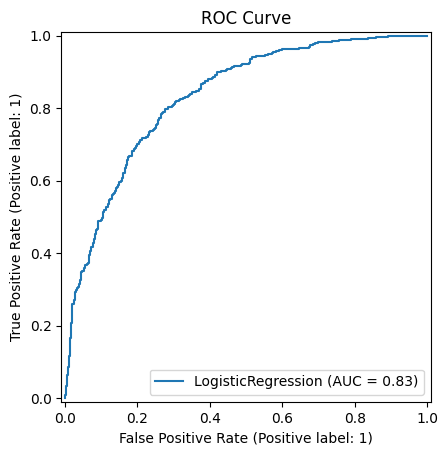

In [64]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_estimator(
    final_model,
    X_test,
    y_test
)

plt.title("ROC Curve")
plt.show()

In [65]:
X.shape

(7032, 19)

In [71]:
import pandas as pd

new_customers = pd.DataFrame({

    'gender': ['Male', 'Female', 'Male', 'Female', 'Male'],

    'SeniorCitizen': [1, 0, 0, 1, 0],

    'Partner': ['No', 'Yes', 'Yes', 'No', 'Yes'],

    'Dependents': ['No', 'Yes', 'No', 'No', 'Yes'],

    'tenure': [2, 72, 24, 12, 60],

    'PhoneService': ['Yes', 'Yes', 'Yes', 'Yes', 'Yes'],

    'MultipleLines': ['Yes', 'Yes', 'No', 'No', 'Yes'],

    'InternetService': [
        'Fiber optic',
        'DSL',
        'DSL',
        'Fiber optic',
        'DSL'
    ],

    'OnlineSecurity': [
        'No',
        'Yes',
        'Yes',
        'No',
        'Yes'
    ],

    'OnlineBackup': [
        'No',
        'Yes',
        'No',
        'No',
        'Yes'
    ],

    'DeviceProtection': [
        'No',
        'Yes',
        'No',
        'No',
        'Yes'
    ],

    'TechSupport': [
        'No',
        'Yes',
        'Yes',
        'No',
        'Yes'
    ],

    'StreamingTV': [
        'Yes',
        'No',
        'Yes',
        'Yes',
        'No'
    ],

    'StreamingMovies': [
        'Yes',
        'No',
        'No',
        'Yes',
        'No'
    ],

    'Contract': [
        'Month-to-month',
        'Two year',
        'One year',
        'Month-to-month',
        'Two year'
    ],

    'PaperlessBilling': [
        'Yes',
        'No',
        'Yes',
        'Yes',
        'No'
    ],

    'PaymentMethod': [
        'Electronic check',
        'Bank transfer (automatic)',
        'Credit card (automatic)',
        'Electronic check',
        'Mailed check'
    ],

    'MonthlyCharges': [
        99.5,
        55.0,
        65.5,
        89.0,
        45.0
    ],

    'TotalCharges': [
        199.0,
        3960.0,
        1572.0,
        1068.0,
        2700.0
    ]
})



In [75]:
new_customers.head(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Male,1,No,No,2,Yes,Yes,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.5,199.0
1,Female,0,Yes,Yes,72,Yes,Yes,DSL,Yes,Yes,Yes,Yes,No,No,Two year,No,Bank transfer (automatic),55.0,3960.0
2,Male,0,Yes,No,24,Yes,No,DSL,Yes,No,No,Yes,Yes,No,One year,Yes,Credit card (automatic),65.5,1572.0
3,Female,1,No,No,12,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,89.0,1068.0
4,Male,0,Yes,Yes,60,Yes,Yes,DSL,Yes,Yes,Yes,Yes,No,No,Two year,No,Mailed check,45.0,2700.0


In [78]:
# Apply preprocessing
new_customers_processed = preprocessor.transform(new_customers)

# Predict
predictions = final_model.predict(new_customers_processed)

# Probabilities
probabilities = final_model.predict_proba(new_customers_processed)[:, 1]

# Results
results = new_customers.copy()

results['Predicted_Churn'] = ['Yes' if p == 1 else 'No' for p in predictions]
results['Churn_Probability'] = probabilities.round(4)

results

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Predicted_Churn,Churn_Probability
0,Male,1,No,No,2,Yes,Yes,Fiber optic,No,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.5,199.0,Yes,0.9348
1,Female,0,Yes,Yes,72,Yes,Yes,DSL,Yes,Yes,...,Yes,No,No,Two year,No,Bank transfer (automatic),55.0,3960.0,No,0.0074
2,Male,0,Yes,No,24,Yes,No,DSL,Yes,No,...,Yes,Yes,No,One year,Yes,Credit card (automatic),65.5,1572.0,No,0.1578
3,Female,1,No,No,12,Yes,No,Fiber optic,No,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,89.0,1068.0,Yes,0.9029
4,Male,0,Yes,Yes,60,Yes,Yes,DSL,Yes,Yes,...,Yes,No,No,Two year,No,Mailed check,45.0,2700.0,No,0.0116
